# BÀI 1 – KHẢO SÁT VÀ TIỀN XỬ LÝ DỮ LIỆU KUAILIVE

## Đề tài
Phân tích hành vi và mức độ gắn kết của người xem livestream

## Nội dung thực hiện
1. Khảo sát dữ liệu
2. Kiểm tra dữ liệu thiếu
3. Kiểm tra dữ liệu trùng lặp
4. Phát hiện và xử lý ngoại lai
5. Chuẩn hóa dữ liệu
6. Rời rạc hóa dữ liệu
7. Xuất dữ liệu sau tiền xử lý

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Đã import thư viện thành công.")

Đã import thư viện thành công.


In [6]:
# Đường dẫn đến dataset 30 thuộc tính
file_path = "../data/raw/KuaiLive_Viewer_Engagement_30_Attributes.xlsx"

# Đọc dữ liệu
df = pd.read_excel(file_path)

print("Đọc dữ liệu thành công!")

Đọc dữ liệu thành công!


In [7]:
print("5 dòng đầu tiên của dataset:")

display(df.head())

5 dòng đầu tiên của dataset:


,Viewer_ID,Live_ID,Streamer_ID,Viewer_Age,Viewer_Gender,Viewer_Country,Viewer_Device_Brand,Viewer_Device_Price,Account_Age_Days,Accumulated_Watch_Count,Accumulated_Watch_Duration,Is_Live_Streamer,Is_Photo_Author,Watch_Time,Click_Count,Comment_Count,Like_Count,Gift_Count,Gift_Value,Has_Comment,Has_Like,Has_Gift,Interaction_Count,Like_Rate,Comment_Rate,Gift_Rate,Engagement_Score,Engagement_Level,Streamer_Gender,Streamer_Age
0,1,1520913,285858,24-30,F,China,HUAWEI,1000-2000,872,50000-100000,0-1000000000,1,1,4519,1,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,3.3665,Medium,F,24-30
1,7,541927,244121,18-23,M,China,IQOO,2000-4000,1490,100000-500000,1000000000-5000000000,1,1,1600101,1,0,1,0,0,0,1,0,1,0.000037,0.0,0.0,5.8529,High,M,24-30
2,19,5056801,392962,12-17,F,China,VIVO,1000-2000,807,100000-500000,5000000000-10000000000,1,1,11329,1,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,3.7341,Medium,M,18-23
3,19,5605873,107543,12-17,F,China,VIVO,1000-2000,807,100000-500000,5000000000-10000000000,1,1,2267,1,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,3.0907,Medium,F,18-23
4,22,1277396,33084,31-40,M,China,HONOR,2000-4000,3220,0-50000,1000000000-5000000000,0,1,26729,1,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,4.0774,High,M,18-23


In [8]:
print("Kích thước dữ liệu:")
print("Số dòng :", df.shape[0])
print("Số cột  :", df.shape[1])
print("Số chiều:", df.ndim)
print("Danh sách các thuộc tính:")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Kích thước dữ liệu:
Số dòng : 20000
Số cột  : 30
Số chiều: 2
Danh sách các thuộc tính:
01. Viewer_ID
02. Live_ID
03. Streamer_ID
04. Viewer_Age
05. Viewer_Gender
06. Viewer_Country
07. Viewer_Device_Brand
08. Viewer_Device_Price
09. Account_Age_Days
10. Accumulated_Watch_Count
11. Accumulated_Watch_Duration
12. Is_Live_Streamer
13. Is_Photo_Author
14. Watch_Time
15. Click_Count
16. Comment_Count
17. Like_Count
18. Gift_Count
19. Gift_Value
20. Has_Comment
21. Has_Like
22. Has_Gift
23. Interaction_Count
24. Like_Rate
25. Comment_Rate
26. Gift_Rate
27. Engagement_Score
28. Engagement_Level
29. Streamer_Gender
30. Streamer_Age


In [9]:
behavior_cols = [
    "Watch_Time",
    "Click_Count",
    "Comment_Count",
    "Like_Count",
    "Gift_Count",
    "Gift_Value"
]

display(df[behavior_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Watch_Time,20000.0,92554.10985,395694.213223,8.0,1743.75,4567.5,23265.25,9087520.0
Click_Count,20000.0,1.15740,0.540870,1.0,1.00,1.0,1.00,14.0
Comment_Count,20000.0,0.03835,0.207078,0.0,0.00,0.0,0.00,6.0
Like_Count,20000.0,0.04085,0.212093,0.0,0.00,0.0,0.00,5.0
Gift_Count,20000.0,0.01445,0.121416,0.0,0.00,0.0,0.00,2.0
Gift_Value,20000.0,0.94350,24.351564,0.0,0.00,0.0,0.00,1344.0


CHECK MISSING


In [10]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Thuộc tính": missing.index,
    "Số giá trị thiếu": missing.values,
    "Tỷ lệ thiếu (%)": (missing.values / len(df) * 100).round(2)
})

display(missing_df)
total_missing = df.isnull().sum().sum()

print("Tổng số ô bị thiếu:", total_missing)

if total_missing == 0:
    print("Kết luận: Dataset không có giá trị thiếu.")
else:
    print("Dataset có giá trị thiếu và cần xử lý.")

,Thuộc tính,Số giá trị thiếu,Tỷ lệ thiếu (%)
0,Viewer_ID,0,0.0
1,Live_ID,0,0.0
2,Streamer_ID,0,0.0
3,Viewer_Age,0,0.0
4,Viewer_Gender,0,0.0
5,Viewer_Country,0,0.0
6,Viewer_Device_Brand,0,0.0
7,Viewer_Device_Price,0,0.0
8,Account_Age_Days,0,0.0
9,Accumulated_Watch_Count,0,0.0


Tổng số ô bị thiếu: 0
Kết luận: Dataset không có giá trị thiếu.


HANDLE MISSING VALUES

In [11]:
df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=np.number).columns

# Điền trung vị cho biến số nếu có missing
for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Điền giá trị phổ biến nhất cho biến phân loại
categorical_cols = df_clean.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_value = df_clean[col].mode()

        if len(mode_value) > 0:
            df_clean[col] = df_clean[col].fillna(mode_value[0])

print("Đã kiểm tra/xử lý giá trị thiếu.")

print("Tổng missing sau xử lý:",
      df_clean.isnull().sum().sum())

Đã kiểm tra/xử lý giá trị thiếu.
Tổng missing sau xử lý: 0


CHECK DUPLICATE

In [12]:
key_cols = [
    "Viewer_ID",
    "Live_ID",
    "Streamer_ID"
]

duplicate_mask = df_clean.duplicated(
    subset=key_cols,
    keep=False
)

duplicate_count = duplicate_mask.sum()

print("Số dòng trùng theo khóa Viewer_ID + Live_ID + Streamer_ID:",
      duplicate_count)

Số dòng trùng theo khóa Viewer_ID + Live_ID + Streamer_ID: 0


In [13]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates(
    subset=key_cols,
    keep="first"
)

after = len(df_clean)

print("Số dòng trước khi xử lý:", before)
print("Số dòng sau khi xử lý  :", after)
print("Số dòng đã loại bỏ     :", before - after)

Số dòng trước khi xử lý: 20000
Số dòng sau khi xử lý  : 20000
Số dòng đã loại bỏ     : 0


CHECK NGOẠI LAI

In [14]:
outlier_results = []

for col in behavior_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    )

    outlier_count = outlier_mask.sum()

    outlier_results.append({
        "Thuộc tính": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Số ngoại lai": outlier_count,
        "Tỷ lệ (%)": outlier_count / len(df_clean) * 100
    })

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df.round(4))

,Thuộc tính,Q1,Q3,IQR,Lower Bound,Upper Bound,Số ngoại lai,Tỷ lệ (%)
0,Watch_Time,1743.75,23265.25,21521.5,-30538.5,55547.5,3258,16.290
1,Click_Count,1.00,1.00,0.0,1.0,1.0,2227,11.135
2,Comment_Count,0.00,0.00,0.0,0.0,0.0,721,3.605
3,Like_Count,0.00,0.00,0.0,0.0,0.0,771,3.855
4,Gift_Count,0.00,0.00,0.0,0.0,0.0,284,1.420
5,Gift_Value,0.00,0.00,0.0,0.0,0.0,284,1.420


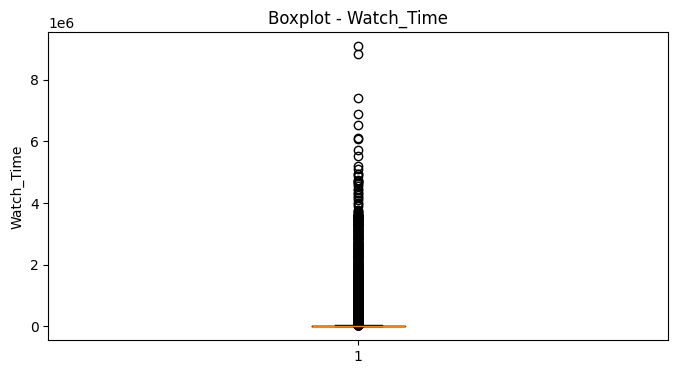

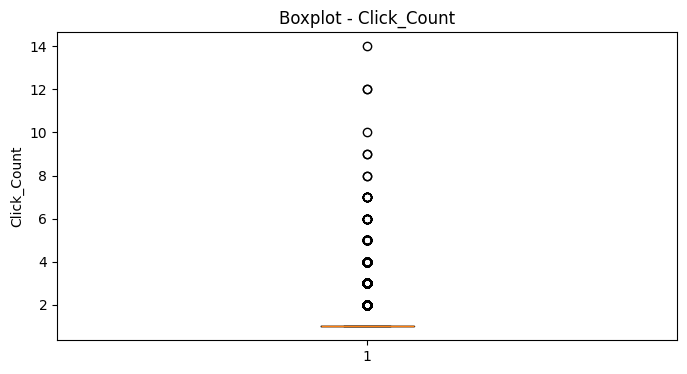

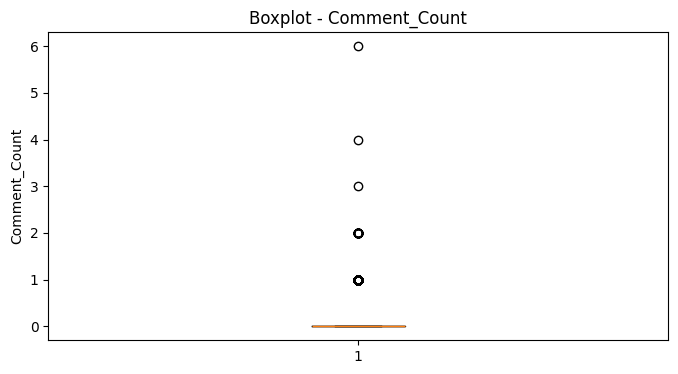

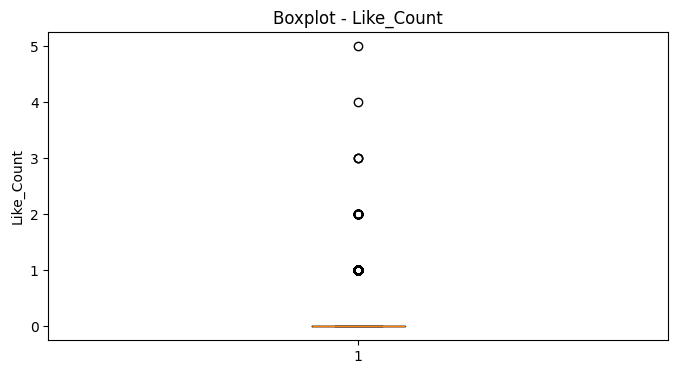

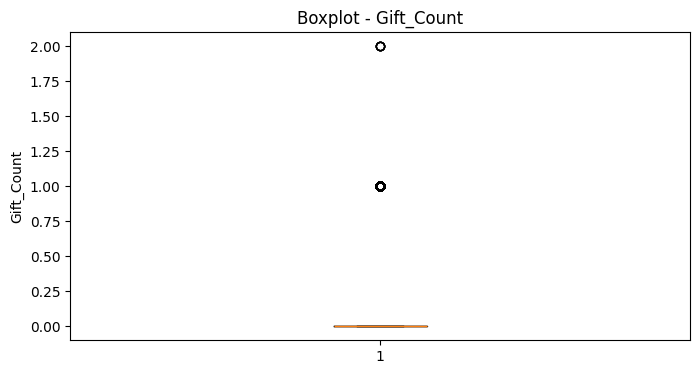

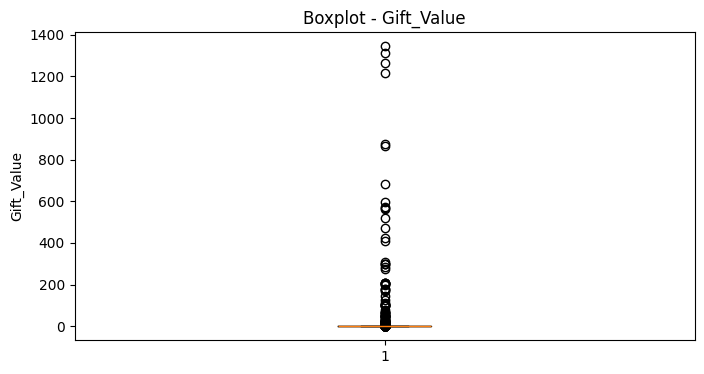

In [15]:
for col in behavior_cols:

    plt.figure(figsize=(8, 4))

    plt.boxplot(df_clean[col].dropna())

    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)

    plt.show()

In [16]:
outlier_file = "../data/processed/outlier_check.xlsx"

outlier_df.to_excel(
    outlier_file,
    index=False
)

print("Đã xuất file kiểm tra ngoại lai:")
print(outlier_file)

Đã xuất file kiểm tra ngoại lai:
../data/processed/outlier_check.xlsx


CHUẨN HOÁ HOẶC RỜI RẠC HOÁ CÁC BIẾN SỐ

1.CHUẨN HOÁ WATCH_TIME


In [17]:
df_processed = df_clean.copy()

df_processed["Log_Watch_Time"] = np.log1p(
    df_processed["Watch_Time"]
)

print("Đã tạo biến Log_Watch_Time.")

display(
    df_processed[
        ["Watch_Time", "Log_Watch_Time"]
    ].head()
)
watch_compare = df_processed[
    ["Watch_Time", "Log_Watch_Time"]
].describe().T

display(watch_compare.round(4))

Đã tạo biến Log_Watch_Time.


,Watch_Time,Log_Watch_Time
0,4519,8.416267
1,1600101,14.285578
2,11329,9.335209
3,2267,7.726654
4,26729,10.193542


,count,mean,std,min,25%,50%,75%,max
Watch_Time,20000.0,92554.1098,395694.2132,8.0000,1743.7500,4567.5000,23265.2500,9.087520e+06
Log_Watch_Time,20000.0,8.9700,1.8977,2.1972,7.4644,8.4269,10.0548,1.602240e+01


Các biến: 
+ Click_Count
+ Comment_Count
+ Like_Count
+ Gift_Count
+ Gift_Value
Có rất nhiều số 0 nên không thể dùng IQR để xoá các giá trị >0
=> ta dùng log1p() để làm giảm ảnh hưởng của phân phối lệch.

In [18]:
log_cols = [
    "Click_Count",
    "Comment_Count",
    "Like_Count",
    "Gift_Count",
    "Gift_Value"
]

for col in log_cols:
    df_processed[f"Log_{col}"] = np.log1p(
        df_processed[col]
    )

print("Đã tạo các biến log cho dữ liệu lệch.")

Đã tạo các biến log cho dữ liệu lệch.


In [19]:
log_result_cols = [
    "Watch_Time",
    "Log_Watch_Time",
    "Click_Count",
    "Log_Click_Count",
    "Comment_Count",
    "Log_Comment_Count",
    "Like_Count",
    "Log_Like_Count",
    "Gift_Count",
    "Log_Gift_Count",
    "Gift_Value",
    "Log_Gift_Value"
]

display(
    df_processed[log_result_cols].describe().T.round(4)
)

,count,mean,std,min,25%,50%,75%,max
Watch_Time,20000.0,92554.1098,395694.2132,8.0000,1743.7500,4567.5000,23265.2500,9.087520e+06
Log_Watch_Time,20000.0,8.9700,1.8977,2.1972,7.4644,8.4269,10.0548,1.602240e+01
Click_Count,20000.0,1.1574,0.5409,1.0000,1.0000,1.0000,1.0000,1.400000e+01
Log_Click_Count,20000.0,0.7500,0.1742,0.6931,0.6931,0.6931,0.6931,2.708100e+00
Comment_Count,20000.0,0.0384,0.2071,0.0000,0.0000,0.0000,0.0000,6.000000e+00
Log_Comment_Count,20000.0,0.0259,0.1353,0.0000,0.0000,0.0000,0.0000,1.945900e+00
Like_Count,20000.0,0.0408,0.2121,0.0000,0.0000,0.0000,0.0000,5.000000e+00
Log_Like_Count,20000.0,0.0276,0.1393,0.0000,0.0000,0.0000,0.0000,1.791800e+00
Gift_Count,20000.0,0.0144,0.1214,0.0000,0.0000,0.0000,0.0000,2.000000e+00
Log_Gift_Count,20000.0,0.0099,0.0831,0.0000,0.0000,0.0000,0.0000,1.098600e+00


CHUẨN HOÁ DỮ LIỆU BẰNG STANDARD_SCALER

In [20]:
scale_cols = [
    "Log_Watch_Time",
    "Log_Click_Count",
    "Log_Comment_Count",
    "Log_Like_Count",
    "Log_Gift_Count",
    "Log_Gift_Value"
]

scaler = StandardScaler()

df_processed[
    [f"Z_{col.replace('Log_', '')}" for col in scale_cols]
] = scaler.fit_transform(
    df_processed[scale_cols]
)

print("Đã chuẩn hóa dữ liệu bằng StandardScaler.")

Đã chuẩn hóa dữ liệu bằng StandardScaler.


In [21]:
normalized_cols = [
    "Z_Watch_Time",
    "Z_Click_Count",
    "Z_Comment_Count",
    "Z_Like_Count",
    "Z_Gift_Count",
    "Z_Gift_Value"
]

normalized_stats = df_processed[
    normalized_cols
].agg(["mean", "std", "min", "max"]).T

display(normalized_stats.round(4))

,mean,std,min,max
Z_Watch_Time,-0.0,1.0,-3.5690,3.7163
Z_Click_Count,-0.0,1.0,-0.3261,11.2416
Z_Comment_Count,0.0,1.0,-0.1912,14.1926
Z_Like_Count,-0.0,1.0,-0.1980,12.6604
Z_Gift_Count,-0.0,1.0,-0.1197,13.1011
Z_Gift_Value,0.0,1.0,-0.0951,21.2100


RỜI RẠC HOÁ WATCH_TIME


In [22]:
df_processed["Watch_Time_Level"] = pd.qcut(
    df_processed["Watch_Time"],
    q=3,
    labels=["Short", "Medium", "Long"],
    duplicates="drop"
)

print("Phân bố mức độ thời gian xem:")

display(
    df_processed["Watch_Time_Level"]
    .value_counts()
    .sort_index()
)

Phân bố mức độ thời gian xem:


Watch_Time_Level
Short     6667
Medium    6666
Long      6667
Name: count, dtype: int64

RỜI RẠC HOÁ LIKE

In [23]:
df_processed["Like_Behavior"] = np.where(
    df_processed["Like_Count"] == 0,
    "No_Like",
    "Liked"
)

display(
    df_processed["Like_Behavior"]
    .value_counts()
)

Like_Behavior
No_Like    19229
Liked        771
Name: count, dtype: int64

RỜI RẠC HOÁ COMMENT

In [24]:
df_processed["Comment_Behavior"] = np.where(
    df_processed["Comment_Count"] == 0,
    "No_Comment",
    "Commented"
)

display(
    df_processed["Comment_Behavior"]
    .value_counts()
)

Comment_Behavior
No_Comment    19279
Commented       721
Name: count, dtype: int64

RỜI RẠC HOÁ GIFT

In [25]:
df_processed["Gift_Behavior"] = np.where(
    df_processed["Gift_Count"] == 0,
    "No_Gift",
    "Gifted"
)

display(
    df_processed["Gift_Behavior"]
    .value_counts()
)

Gift_Behavior
No_Gift    19716
Gifted       284
Name: count, dtype: int64

RỜI RẠC HOÁ GIFT VALUE

In [26]:
positive_gift = df_processed.loc[
    df_processed["Gift_Value"] > 0,
    "Gift_Value"
]

gift_mean = positive_gift.mean()

print("Giá trị quà trung bình đối với các phiên có tặng quà:",
      round(gift_mean, 4))

Giá trị quà trung bình đối với các phiên có tặng quà: 66.4437


In [27]:
df_processed["Gift_Value_Level"] = np.select(
    [
        df_processed["Gift_Value"] == 0,
        (
            (df_processed["Gift_Value"] > 0) &
            (df_processed["Gift_Value"] <= gift_mean)
        ),
        df_processed["Gift_Value"] > gift_mean
    ],
    [
        "No_Gift",
        "Low_Gift",
        "High_Gift"
    ],
    default="No_Gift"
)

display(
    df_processed["Gift_Value_Level"]
    .value_counts()
)

Gift_Value_Level
No_Gift      19716
Low_Gift       239
High_Gift       45
Name: count, dtype: int64

KHẢO SÁT ENGAGEMENT LEVEL

In [28]:
print("Phân bố Engagement Level:")

display(
    df_processed["Engagement_Level"]
    .value_counts()
    .sort_index()
)

Phân bố Engagement Level:


Engagement_Level
High      6667
Low       6666
Medium    6667
Name: count, dtype: int64

KIỂM TRA DATASET SAU TIỀN SỬ LÝ

In [29]:
print("Kích thước dataset sau tiền xử lý:")

print("Số dòng:", df_processed.shape[0])
print("Số cột :", df_processed.shape[1])

Kích thước dataset sau tiền xử lý:
Số dòng: 20000
Số cột : 47


KIỂM TRA LẠI MISSING VÀ DUPLICATE

In [30]:
final_missing = df_processed.isnull().sum().sum()

print("Tổng số giá trị thiếu sau tiền xử lý:",
      final_missing)
final_duplicates = df_processed.duplicated(
    subset=key_cols
).sum()

print(
    "Số dòng trùng sau tiền xử lý:",
    final_duplicates
)

Tổng số giá trị thiếu sau tiền xử lý: 0
Số dòng trùng sau tiền xử lý: 0


XUẤT DATASET

In [31]:


csv_file = "../data/processed/dataset_30_attributes_processed.csv"

df_processed.to_csv(
    csv_file,
    index=False,
    encoding="utf-8-sig"
)

print("Đã xuất CSV:")
print(csv_file)

Đã xuất CSV:
../data/processed/dataset_30_attributes_processed.csv
